# Makemore Lesson 02

Live notes and code while following Andrej Karpathy's makemore Part 2.

## Session Goals

- Follow the lesson actively.
- Keep code runnable.
- Add short notes only when a concept is confusing or important.


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


## Data


In [2]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8], len(words)


(['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'],
 32033)

## Notes

- 


In [ ]:
# stoi, itos

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [4]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [5]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [13]:
C = torch.randn((27, 2)) #Embedding means representing discrete tokens as continuous vectors.

C

tensor([[ 0.2401, -0.5400],
        [-1.1058, -1.0842],
        [ 1.2614,  0.7596],
        [-0.7423, -1.3111],
        [-0.4029,  1.4708],
        [ 0.9855,  1.0697],
        [ 1.7095,  0.8275],
        [ 0.0625,  1.2957],
        [-1.0032,  0.3002],
        [ 0.8014, -0.1413],
        [-0.7550, -0.1045],
        [-2.0373, -0.1113],
        [ 0.0604,  0.6716],
        [-2.4536, -0.2455],
        [-0.6730,  0.8873],
        [ 0.8212,  0.6360],
        [ 0.4380,  2.8910],
        [-2.3392, -0.8821],
        [ 0.6182,  0.1859],
        [-0.1402,  1.5047],
        [ 0.0687, -0.0404],
        [ 2.0149,  1.6668],
        [ 0.0938,  0.3313],
        [-0.1175,  0.1495],
        [-0.6222,  1.8209],
        [ 1.5911, -0.4088],
        [ 0.6632,  0.5942]])

In [14]:
C[5]

tensor([0.9855, 1.0697])

In [17]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([0.9855, 1.0697])

In [28]:
C[X]

tensor([[[ 0.2401, -0.5400],
         [ 0.2401, -0.5400],
         [ 0.2401, -0.5400]],

        [[ 0.2401, -0.5400],
         [ 0.2401, -0.5400],
         [ 0.9855,  1.0697]],

        [[ 0.2401, -0.5400],
         [ 0.9855,  1.0697],
         [-2.4536, -0.2455]],

        [[ 0.9855,  1.0697],
         [-2.4536, -0.2455],
         [-2.4536, -0.2455]],

        [[-2.4536, -0.2455],
         [-2.4536, -0.2455],
         [-1.1058, -1.0842]],

        [[ 0.2401, -0.5400],
         [ 0.2401, -0.5400],
         [ 0.2401, -0.5400]],

        [[ 0.2401, -0.5400],
         [ 0.2401, -0.5400],
         [ 0.8212,  0.6360]],

        [[ 0.2401, -0.5400],
         [ 0.8212,  0.6360],
         [ 0.0604,  0.6716]],

        [[ 0.8212,  0.6360],
         [ 0.0604,  0.6716],
         [ 0.8014, -0.1413]],

        [[ 0.0604,  0.6716],
         [ 0.8014, -0.1413],
         [ 0.0938,  0.3313]],

        [[ 0.8014, -0.1413],
         [ 0.0938,  0.3313],
         [ 0.8014, -0.1413]],

        [[ 0.0938,  0

In [73]:
emb = C[X]
emb.shape

torch.Size([32, 3, 10])

In [74]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [75]:
emb @ W1 + b1 # make emb.shape into [32, 6]

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x10 and 6x100)

In [76]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 30])

In [77]:
torch.cat(torch.unbind(emb, 1), 1).shape

torch.Size([32, 30])

In [78]:
emb.view(32, 6)

RuntimeError: shape '[32, 6]' is invalid for input of size 960

In [70]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # broadcasting

RuntimeError: mat1 and mat2 shapes cannot be multiplied (160x6 and 30x200)

In [71]:
h

tensor([[-0.6323,  0.0997,  0.5766,  ...,  0.8827,  0.9157,  0.6947],
        [-0.9222, -0.7665, -0.6345,  ..., -0.5993,  0.9993,  0.9999],
        [-0.7243,  0.4586,  0.9959,  ...,  0.7964,  0.9859, -0.9977],
        ...,
        [-0.9999,  0.9637,  0.9830,  ...,  0.7961, -0.3976, -0.9813],
        [ 0.3455,  0.9991,  0.9777,  ...,  0.6518, -0.9963,  0.9416],
        [ 0.9992, -0.5394,  0.9135,  ...,  0.6168, -0.3008, -0.2494]])

In [51]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [53]:
logits = h @ W2 + b2
logits

tensor([[ 2.2481e+00,  1.4140e+00,  1.0190e+01, -2.1688e+00, -1.5032e+01,
         -1.0847e+01,  8.5508e+00,  7.2052e+00,  5.6489e+00, -2.6964e+00,
          8.8579e+00,  1.2941e+00, -2.9302e+00,  2.0911e+00, -5.2167e+00,
          2.0205e+00,  1.3848e+01,  3.8618e+00, -8.6924e+00,  1.0546e+01,
         -3.2035e-01, -1.0785e+01, -2.9228e-03, -4.9020e+00,  6.7768e+00,
          1.0169e+01,  4.8376e+00],
        [ 5.9160e+00,  4.3860e+00,  3.0447e+00,  8.2896e+00, -1.9437e+01,
         -9.2739e+00,  7.4596e+00,  1.5535e+01, -2.1810e+00,  9.5246e+00,
          1.1361e+01,  7.4568e+00,  4.7111e+00, -1.9909e+00, -1.4243e+00,
         -1.3993e+01, -1.5282e+01,  6.9501e+00,  2.2496e+00,  1.2508e+01,
         -1.8977e+00,  3.5606e+00, -1.6162e+01,  5.8136e+00,  9.1366e-01,
          2.8360e+00,  5.0675e+00],
        [-1.8615e+00, -9.5391e+00,  1.2084e+00, -1.4849e+01, -9.8663e+00,
         -7.4454e+00, -3.6509e-01,  5.6241e+00, -2.7869e-01,  8.8187e+00,
          7.5854e+00, -2.2570e+00, -1.48

In [54]:
counts = logits.exp()
prob = counts / counts.sum(1, keepdim=True)

In [55]:
prob[0].sum()

tensor(1.0000)

In [57]:
loss = -prob[torch.arange(32), Y].log().mean() 
loss

#prob: 32 个样本，每个样本对 27 个字符的预测概率
#Y: 32 个样本，每个样本真正的下一个字符 index

tensor(18.9255)

In [201]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g)
W2 = torch.randn((100, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [83]:
X.shape, Y.shape

(torch.Size([32, 3]), torch.Size([32]))

In [202]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # broadcasting
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Y)
#  backward & forward pass can be more efficient
loss

tensor(19.5052)

In [16]:
for p in parameters:
    p.requires_grad = True

In [189]:

for _ in range(10):
    emb = C[X]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # broadcasting
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    # print(loss.item())
    
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data += -0.1 * p.grad


print(loss.item())

11.051871299743652


In [151]:
logits.max(0)

torch.return_types.max(
values=tensor([ 3.6559,  4.2943,  1.8291,  2.1558,  1.4713,  2.9214, -0.8792,  1.2760,
         1.7082,  2.9131,  1.9287,  1.9502,  2.0623,  2.6158,  2.7231,  2.8745,
         0.8700, -0.3969,  2.5512,  1.7560,  1.8223,  1.4366,  1.0339, -0.2632,
         0.1472,  2.0464,  0.9484], grad_fn=<MaxBackward0>),
indices=tensor([ 5, 26, 21, 21, 30, 26, 26, 23, 21, 11, 21, 21, 21, 21, 21, 11, 21, 21,
         4, 21, 21, 11,  9, 14, 21, 11, 15]))

In [190]:

# in mini-batch

for _ in range(10):
    # in mini batch construct

    ix = torch.randint(0, X.shape[0], (32,))
    
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # broadcasting

    # C[X] gives us embeddings with shape (batch_size, block_size, embedding_dim).
    # view flattens each training example into one long vector so it can go into the hidden layer.
    
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # print(loss.item())
    
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    for p in parameters:
        p.data += -1 * p.grad


print(loss.item())

11.731439590454102
13.707672119140625
13.200716972351074
11.643522262573242
9.676043510437012
14.40159797668457
8.536535263061523
10.638811111450195
10.130681037902832
10.484857559204102
10.484857559204102


In [17]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

#Instead of trying learning rates linearly, we try them exponentially from 10^-3 to 10^0, because learning rates are best searched over orders of magnitude.

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [194]:

# in mini-batch

lri = []
lossi = []

for i in range(1000):
    # in mini batch construct

    ix = torch.randint(0, X.shape[0], (32,))
    
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # broadcasting

    # C[X] gives us embeddings with shape (batch_size, block_size, embedding_dim).
    # view flattens each training example into one long vector so it can go into the hidden layer.
    
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    print(loss.item())
    # print(loss.item())
    
    for p in parameters:
        p.grad = None
    
    loss.backward()

    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

    lri.append(lre[i]) #We update the model with the actual learning rate lrs[i], but we plot the exponent lre[i] because learning rates are easier to inspect on a log scale.
    lossi.append(loss.item())


# print(loss.item())

6.6453399658203125
5.45924711227417
6.2572197914123535
5.312124729156494
6.340160846710205
6.402351379394531
4.874738693237305
5.565861701965332
6.116034507751465
8.270783424377441
6.583806991577148
5.547736167907715
6.173192977905273
6.084716320037842
7.465054988861084
6.567595481872559
6.689342498779297
6.577465057373047
5.174411773681641
6.6869611740112305
8.272883415222168
5.875013828277588
6.687213897705078
5.924034595489502
6.057997226715088
5.653182029724121
6.12287712097168
6.561545372009277
6.26231575012207
6.916330337524414
5.290211200714111
5.78041934967041
7.428589820861816
6.758601188659668
5.591042518615723
6.440125942230225
6.427664756774902
6.014451026916504
5.75811243057251
5.4973626136779785
6.105654239654541
5.725642204284668
5.5727667808532715
7.4992356300354
6.233799934387207
6.524387359619141
6.811615943908691
6.221293926239014
5.7456955909729
8.365106582641602
6.866185188293457
5.505319118499756
6.4908061027526855
5.429155349731445
5.85444450378418
6.424666404724

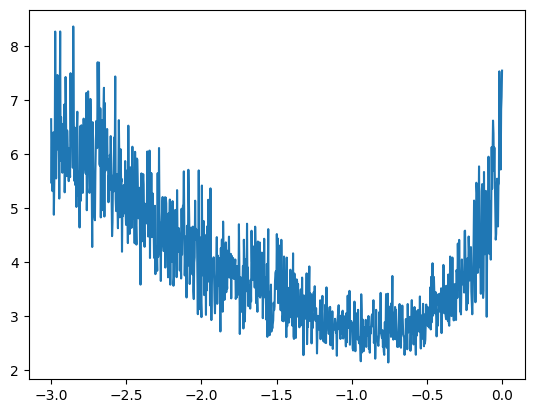

In [196]:
plt.plot(lri, lossi)

In [204]:

# in mini-batch

# lri = []
# lossi = []

for i in range(100000):
    # in mini batch construct

    ix = torch.randint(0, X.shape[0], (32,))
    
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # broadcasting

    # C[X] gives us embeddings with shape (batch_size, block_size, embedding_dim).
    # view flattens each training example into one long vector so it can go into the hidden layer.
    
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[ix])
    # print(loss.item())
    # print(loss.item())
    
    for p in parameters:
        p.grad = None
    
    loss.backward()

    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    # lri.append(lre[i]) #We update the model with the actual learning rate lrs[i], but we plot the exponent lre[i] because learning rates are easier to inspect on a log scale.
    # lossi.append(loss.item())


# print(loss.item())

In [206]:
emb = C[X]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # broadcasting
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Y)
#  backward & forward pass can be more efficient
loss

tensor(2.3006, grad_fn=<NllLossBackward0>)

In [ ]:
# traning split, dev/validation split, test split
# 80%, 10%, 10%

In [6]:
block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [14]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [ ]:
len(words)

In [10]:
n1

25626

In [48]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [49]:
for p in parameters:
    p.requires_grad = True

In [50]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
lrs

tensor([0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0010, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011,
        0.0011, 0.0011, 0.0011, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012,
        0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012, 0.0013, 0.0013, 0.0013,
        0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0013, 0.0014,
        0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014, 0.0014,
        0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015, 0.0015,
        0.0015, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016, 0.0016,
        0.0016, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017, 0.0017,
        0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0018, 0.0019,
        0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0019, 0.0020, 0.0020,
        0.0020, 0.0020, 0.0020, 0.0020, 0.0020, 0.0021, 0.0021, 0.0021, 0.0021,
        0.0021, 0.0021, 0.0021, 0.0022, 

In [ ]:
lri = []
lossi = []
stepi = []

In [51]:


for i in range(200000):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])
  #print(loss.item())
  
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  # lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

In [25]:
print(loss.item())

2.6958813667297363


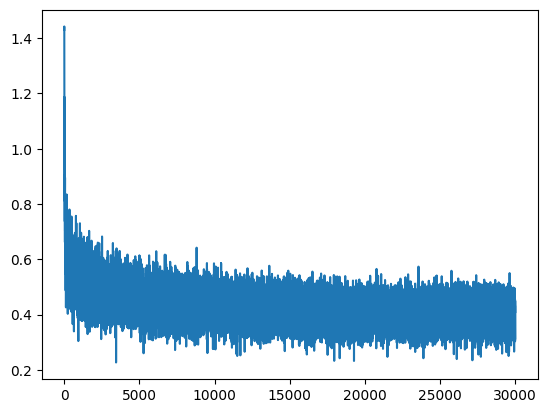

In [38]:
plt.plot(stepi, lossi)

In [52]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # broadcasting
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Ytr)
#  backward & forward pass can be more efficient
loss

tensor(2.1238, grad_fn=<NllLossBackward0>)

In [53]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # broadcasting
logits = h @ W2 + b2
# counts = logits.exp()
# prob = counts / counts.sum(1, keepdim=True)
# loss = -prob[torch.arange(32), Y].log().mean()
loss = F.cross_entropy(logits, Ydev)
#  backward & forward pass can be more efficient
loss

tensor(2.1609, grad_fn=<NllLossBackward0>)